In [45]:
import csv
import numpy as np

tr_in = np.genfromtxt('train_in.csv', delimiter=",")
tr_out = np.genfromtxt('train_out.csv', delimiter=",")
te_in = np.genfromtxt('test_in.csv', delimiter=",")
te_out = np.genfromtxt('test_out.csv', delimiter=",")

classifier=[np.zeros(257) for x in range(10)]


In [46]:
def grcalc(data, labels, classifier):
    gradient=[np.zeros(257) for x in range(10)]
    error=np.zeros(len(classifier))
    for ind_i, image in enumerate(data):
        for ind_c, c in enumerate(classifier):
            if labels[ind_i]==ind_c:
                y=1
            else: y=0
            error[ind_c]=classifier[ind_c][0]+classifier[ind_c][1:257]@image-y
            
            gradient[ind_c][0]+=2*error[ind_c]
            for ind_p, pixel in enumerate(image):
                gradient[ind_c][ind_p+1]+=2*error[ind_c]*pixel
    return gradient
    

In [47]:
def train(data, labels, classifier, alpha):
    
    gradient=grcalc(data, labels, classifier)

    sub=gradient*np.array(alpha)

    newp=classifier-sub

    return newp

In [48]:
def aloss(data, labels, classifier):
    error=np.zeros(len(classifier))
    for ind_i, image in enumerate(data):
        for ind_c, c in enumerate(classifier):
            if labels[ind_i]==ind_c:
                y=1
            else: y=0
            error[ind_c]+=(classifier[ind_c][0]+classifier[ind_c][1:257]@image-y)**2
    sumloss=np.sum(error)
    return sumloss/len(data)

In [49]:
def predict(data, classifier):
    maxpred=np.empty(len(data))
    curpred=np.empty(len(classifier))
    for ind_i, image in enumerate(data):
        for ind_c, c in enumerate(classifier):
            curpred[ind_c]=classifier[ind_c][1:257]@image+classifier[ind_c][0]
        maxpred[ind_i]=np.argmax(curpred)
    return maxpred

In [50]:
def acc(predict, labels):
    accu=0
    for ind_i, image in enumerate(predict):
        if predict[ind_i]==labels[ind_i]:
            accu+=1
    return accu*100/len(predict)

In [ ]:
#Visualizing the network's performance on the training set

print("Visualizing the network's performance on the training set")

print(f"Epoch 0:")
p=predict(tr_in, classifier)
l=aloss(tr_in, tr_out, classifier)
a=acc(p,tr_out)
lr=2.5e-6 #learning rate
num_epochs=10
print(f"Average loss: {l}, Accuracy: {a:.2f}%")

newl=[l]
newa=[a]

for epoch in range(1, num_epochs+1):
    classifier = train(tr_in, tr_out, classifier, lr)
    p=predict(tr_in, classifier)
    newl.append(aloss(tr_in, tr_out, classifier))
    newa.append(acc(p, tr_out))

    print(f"\nEpoch {epoch}:")
    print(f"Average loss: {newl[epoch]}, Accuracy: {newa[epoch]:.2f}%")

Epoch 0:
Average loss: 1.0, Accuracy: 18.69%

Epoch 1:
Average loss: 0.8157419467847705, Accuracy: 34.15%

Epoch 2:
Average loss: 0.7508738971082426, Accuracy: 42.06%

Epoch 3:
Average loss: 0.7011196319322989, Accuracy: 49.68%

Epoch 4:
Average loss: 0.660799184229601, Accuracy: 56.47%

Epoch 5:
Average loss: 0.6275435491228559, Accuracy: 61.10%

Epoch 6:
Average loss: 0.5996804110632497, Accuracy: 65.55%

Epoch 7:
Average loss: 0.5759909844032569, Accuracy: 68.83%

Epoch 8:
Average loss: 0.555578646998745, Accuracy: 70.94%

Epoch 9:
Average loss: 0.5377774242468784, Accuracy: 73.23%

Epoch 10:
Average loss: 0.5220874039492115, Accuracy: 74.99%


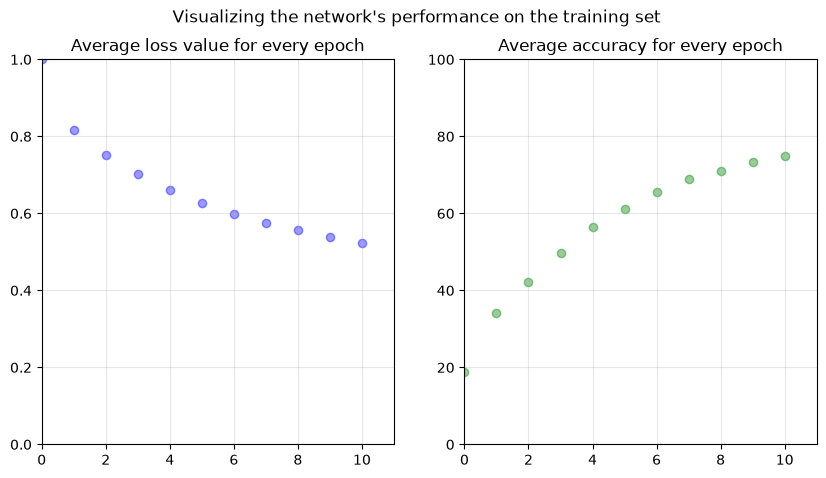

In [55]:
#Visualizing average loss and accuracy

import matplotlib.pyplot as plt

fig1, ax1=plt.subplots(1, 2, figsize=(10,5))

epochs=list(range(len(newl)))
  
fig1.suptitle("Visualizing the network's performance on the training set")

ax1[0].set_xlim(right=num_epochs+1)
ax1[0].set_ylim(bottom=0, top=1)
ax1[0].scatter(epochs, newl, c="b", alpha=0.4)  
ax1[0].set_title('Average loss value for every epoch')
ax1[0].grid(True, alpha=0.3)


ax1[1].set_xlim(right=num_epochs+1)
ax1[1].set_ylim(bottom=0, top=100)
ax1[1].scatter(epochs, newa, c="g", alpha=0.4)  
ax1[1].set_title('Average accuracy for every epoch')
ax1[1].grid(True, alpha=0.3)